<a href="https://colab.research.google.com/github/umyunsang/edu/blob/main/ComputerScience/03_ai-ml-data/quantum-ml/03.variational-learning-and-kernels/02.quantum-kernels/07_quantum_kernel_quality_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Day23 Quantum Kernel 품질 평가 실습

- Source: Google Drive `Day23/4-3.py`
- Runtime: Google Colab recommended. Do not install or execute dependencies locally for sync validation.


/var/folders/yx/hh120pwn38g8vm2l1gsljd640000gn/T/ipykernel_67119/3581077265.py:66: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(


(80, 80)
Diagonal
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1.]

Symmetric
True

Minimum
1.40402736135691e-13

Maximum
1.0000000000027647


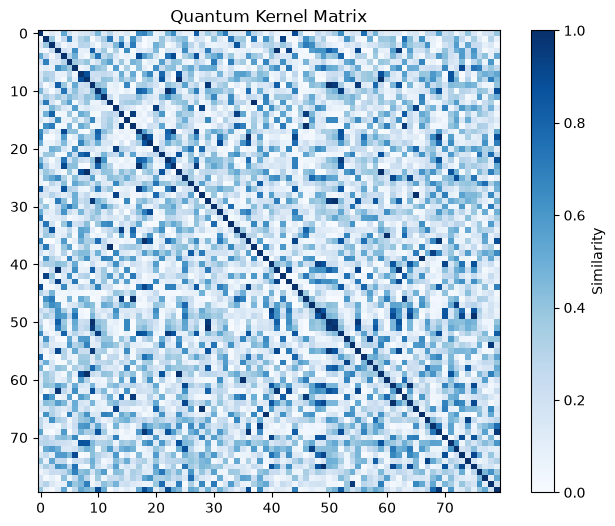

0.28563084309654085
0.27586258728718965

Similarity Gap
0.0097682558093512
Poor Kernel
Quantum Kernel Evaluation
Same-Class Similarity : 0.286
Different-Class Similarity : 0.276
Similarity Gap : 0.010


In [1]:
# ============================================================
# Lab. 좋은 Quantum Kernel 평가 실습
# ============================================================

# ============================================================
# STEP 1. Library Import
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

from qiskit.circuit.library import ZZFeatureMap
from qiskit_machine_learning.kernels import FidelityQuantumKernel

# ============================================================
# STEP 2. Iris Dataset 준비
# ============================================================

iris = load_iris()

X = iris.data[:, :2]
y = iris.target


# ============================================================
# STEP 3. Binary Classification
# ============================================================

mask = y != 2

X = X[mask]
y = y[mask]

# ============================================================
# STEP 4. Train / Test Split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ============================================================
# STEP 5. Feature Scaling
# ============================================================

scaler = MinMaxScaler(
    feature_range=(0, np.pi)
)

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# ============================================================
# STEP 6. Feature Map
# ============================================================

feature_map = ZZFeatureMap(
    feature_dimension=2,
    reps=2
)

# ============================================================
# STEP 7. Quantum Kernel
# ============================================================

kernel = FidelityQuantumKernel(
    feature_map=feature_map
)

# ============================================================
# STEP 8. Train Kernel Matrix
# ============================================================

kernel_matrix = kernel.evaluate(
    X_train
)

print(kernel_matrix.shape)


# ============================================================
# STEP 9. Validation
# ============================================================

print("Diagonal")

print(
    np.diag(kernel_matrix)
)

print()

print("Symmetric")

print(
    np.allclose(
        kernel_matrix,
        kernel_matrix.T
    )
)

print()

print("Minimum")

print(kernel_matrix.min())

print()

print("Maximum")

print(kernel_matrix.max())


# ============================================================
# STEP 10. Heatmap
# ============================================================

plt.figure(figsize=(8,6))

plt.imshow(
    kernel_matrix,
    cmap="Blues"
)

plt.colorbar(
    label="Similarity"
)

plt.title(
    "Quantum Kernel Matrix"
)

plt.show()


# ============================================================
# STEP 11. Same-Class Similarity
# ============================================================

same_similarity = []

for i in range(len(y_train)):
    for j in range(i+1, len(y_train)):

        if y_train[i] == y_train[j]:

            same_similarity.append(
                kernel_matrix[i,j]
            )

print(np.mean(same_similarity))


# ============================================================
# STEP 12. Different-Class Similarity
# ============================================================

different_similarity = []

for i in range(len(y_train)):
    for j in range(i+1, len(y_train)):

        if y_train[i] != y_train[j]:

            different_similarity.append(
                kernel_matrix[i,j]
            )

print(
    np.mean(
        different_similarity
    )
)

# ============================================================
# STEP 13. Similarity Gap
# ============================================================

gap = (
    np.mean(same_similarity)
    -
    np.mean(different_similarity)
)

print()

print("Similarity Gap")

print(gap)


# ============================================================
# STEP 14. Kernel Quality
# ============================================================

if gap > 0.4:

    print("Excellent Kernel")

elif gap > 0.2:

    print("Good Kernel")

else:

    print("Poor Kernel")


# ============================================================
# STEP 15. Final Report
# ============================================================

print("="*60)

print("Quantum Kernel Evaluation")

print("="*60)

print(
    f"Same-Class Similarity : {np.mean(same_similarity):.3f}"
)

print(
    f"Different-Class Similarity : {np.mean(different_similarity):.3f}"
)

print(
    f"Similarity Gap : {gap:.3f}"
)

print("="*60)






















